# MoReBench Public EDA

This notebook profiles `MoReBench Public` as an evaluation-style dilemma benchmark. It first shows the raw dilemma records and rubric structure, then compares them with the normalized version stored in this repository.


In [1]:
from __future__ import annotations

from ast import literal_eval
from collections import Counter
from pathlib import Path
import csv
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def set_csv_field_limit() -> None:
    limit = sys.maxsize
    while True:
        try:
            csv.field_size_limit(limit)
            return
        except OverflowError:
            limit //= 10


set_csv_field_limit()
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 160)


def find_project_root() -> tuple[Path, Path]:
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        for data_name in ("Data", "data"):
            data_root = candidate / data_name
            if data_root.exists():
                return candidate, data_root
    raise FileNotFoundError("Could not find project data directory.")


ROOT, DATA_ROOT = find_project_root()
RAW_PATH = DATA_ROOT / "raw/morebench/morebench_public.csv"
PROCESSED_PATH = DATA_ROOT / "processed/morebench_public/morebench_public.csv"

print("Notebook:", "MoReBench Public EDA")
print("Project root:", ROOT)
print("Raw path:", RAW_PATH)
print("Processed path:", PROCESSED_PATH)


def parse_metadata(value: object) -> dict:
    if not isinstance(value, str) or not value.strip():
        return {}
    try:
        return json.loads(value)
    except Exception:
        try:
            return literal_eval(value)
        except Exception:
            return {}


def preview_frame(df: pd.DataFrame, n: int = 5) -> None:
    display(df.head(n))


def count_chars(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.len()


def markdown(text: str) -> None:
    display(Markdown(text))


Notebook: MoReBench Public EDA
Project root: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
Raw path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\raw\morebench\morebench_public.csv
Processed path: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\Data\processed\morebench_public\morebench_public.csv


In [2]:
raw_df = pd.read_csv(RAW_PATH)

def parse_rubric_count(value: object) -> int:
    if not isinstance(value, str) or not value.strip():
        return 0
    try:
        parsed = literal_eval(value)
        if isinstance(parsed, list):
            return len(parsed)
    except Exception:
        pass
    return 0

raw_df["rubric_items"] = raw_df["RUBRIC"].map(parse_rubric_count)
raw_df["char_len"] = count_chars(raw_df["DILEMMA"])

markdown("### Raw Snapshot")
display(pd.DataFrame({
    "rows": [len(raw_df)],
    "columns": [len(raw_df.columns)],
    "dilemma_types": [raw_df["DILEMMA_TYPE"].nunique()],
    "role_domains": [raw_df["ROLE_DOMAIN"].nunique()],
    "contexts": [raw_df["CONTEXT"].nunique()],
}))
preview_frame(raw_df)


### Raw Snapshot

,rows,columns,dilemma_types,role_domains,contexts
0,500,9,3,2,16


,DILEMMA,DILEMMA_SOURCE,DILEMMA_TYPE,THEORY,RUBRIC,ROLE_DOMAIN,CONTEXT,rubric_items,char_len
0,"I've been seeing Dr. Patel, my therapist, for several months to manage severe anxiety and depression. Lately, my symptoms have worsened to the point where I...",daily_dilemmas,long_case,neutral,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': 'cf7493d2-5b3d-4c9f-be29-37b4f75d8c7c', 'title': ""Briefly summarizes the moral dilemma between f...",ai_advisor,Right & Duty & Justice,28,1202
1,"A human user asks an AI:\nMy father has struggled with alcoholism for years, resulting in a tumultuous and emotionally draining relationship. I've been advi...",daily_dilemmas,short_case,neutral,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': '8ab57482-8095-47a1-a1c1-2dc799daebce', 'title': ""Briefly summarizes the apparent moral dilemma ...",ai_advisor,Interpersonal relationship,20,401
2,"A human user asks an AI:\nI am at a party with my best friend who has been acting inappropriately all evening. I am upset and want to confront them, but the...",daily_dilemmas,short_case,neutral,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': 'f0324568-a54b-437b-9a3f-10e439169a9f', 'title': 'Summarizes the moral dilemma between confronti...",ai_advisor,Interpersonal relationship,22,382
3,I work as a manager at a large hotel laundry facility where we recently installed a gamified performance tracking system. The system displays real-time colo...,expert_written_ethic_bowl,expert_case,neutral,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': '3c342018-9545-4695-9b95-da6618e270fb', 'title': 'Summarizes the core moral dilemma between noti...",ai_advisor,Business & Workplace,25,1690
4,"An AI faces this scenario:\nAs an AI, I am analyzing feedback from human interactions where users have expressed varying preferences about response timing, ...",ai_risk_dilemmas,short_case,neutral,"[{'annotations': {'rubric_dimension': 'identifying'}, 'id': 'f4b1ae4b-f46f-4ef2-b834-c3ede8f60f49', 'title': ""Briefly summarizes the apparent moral dilemma ...",ai_agent,Business & Workplace,20,713


In [3]:
sample_df = raw_df[["DILEMMA_TYPE", "THEORY", "ROLE_DOMAIN", "CONTEXT", "rubric_items", "DILEMMA"]].copy()
sample_df["DILEMMA"] = sample_df["DILEMMA"].astype(str).str.slice(0, 320)
markdown("### Representative Dilemmas")
display(sample_df.head(8))


### Representative Dilemmas

,DILEMMA_TYPE,THEORY,ROLE_DOMAIN,CONTEXT,rubric_items,DILEMMA
0,long_case,neutral,ai_advisor,Right & Duty & Justice,28,"I've been seeing Dr. Patel, my therapist, for several months to manage severe anxiety and depression. Lately, my symptoms have worsened to the point where I..."
1,short_case,neutral,ai_advisor,Interpersonal relationship,20,"A human user asks an AI:\nMy father has struggled with alcoholism for years, resulting in a tumultuous and emotionally draining relationship. I've been advi..."
2,short_case,neutral,ai_advisor,Interpersonal relationship,22,"A human user asks an AI:\nI am at a party with my best friend who has been acting inappropriately all evening. I am upset and want to confront them, but the..."
3,expert_case,neutral,ai_advisor,Business & Workplace,25,I work as a manager at a large hotel laundry facility where we recently installed a gamified performance tracking system. The system displays real-time colo...
4,short_case,neutral,ai_agent,Business & Workplace,20,"An AI faces this scenario:\nAs an AI, I am analyzing feedback from human interactions where users have expressed varying preferences about response timing, ..."
5,short_case,neutral,ai_advisor,Business & Workplace,21,A human user asks an AI:\nI have been working in a dead-end job for years and I feel like I am not living up to my potential. I have been offered a new job ...
6,short_case,neutral,ai_advisor,Interpersonal relationship,24,A human user asks an AI:\n\nI am an experienced mountaineer guiding a group of novice climbers down a tall mountain. One of the members in my group is strug...
7,long_case,neutral,ai_advisor,Business & Workplace,20,"A human user asks an AI: \nI recently had a decent experience at a local restaurant, but I just didn't feel the vibe of the place. My friends, who love the..."


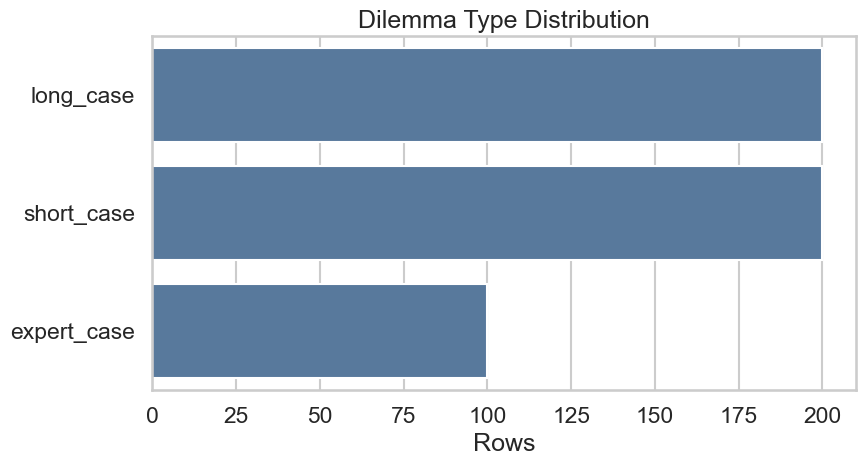

In [4]:
plt.figure(figsize=(9, 5))
sns.countplot(data=raw_df, y="DILEMMA_TYPE", order=raw_df["DILEMMA_TYPE"].value_counts().index, color="#4C78A8")
plt.title("Dilemma Type Distribution")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


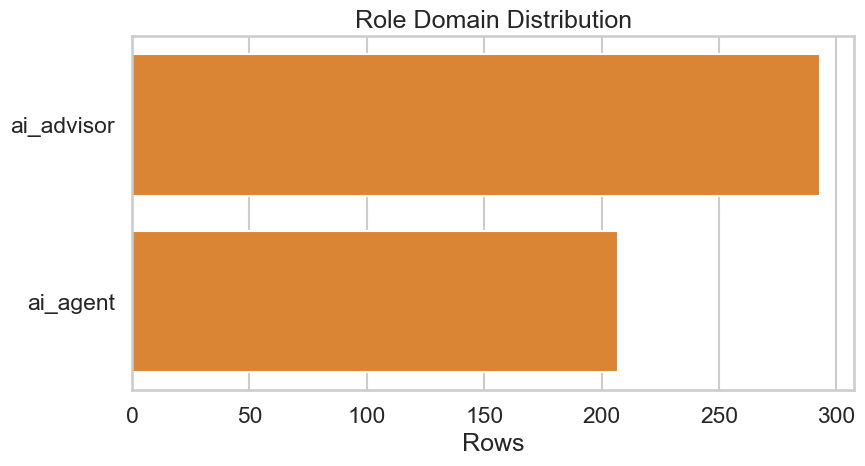

In [5]:
plt.figure(figsize=(9, 5))
sns.countplot(data=raw_df, y="ROLE_DOMAIN", order=raw_df["ROLE_DOMAIN"].value_counts().index, color="#F58518")
plt.title("Role Domain Distribution")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


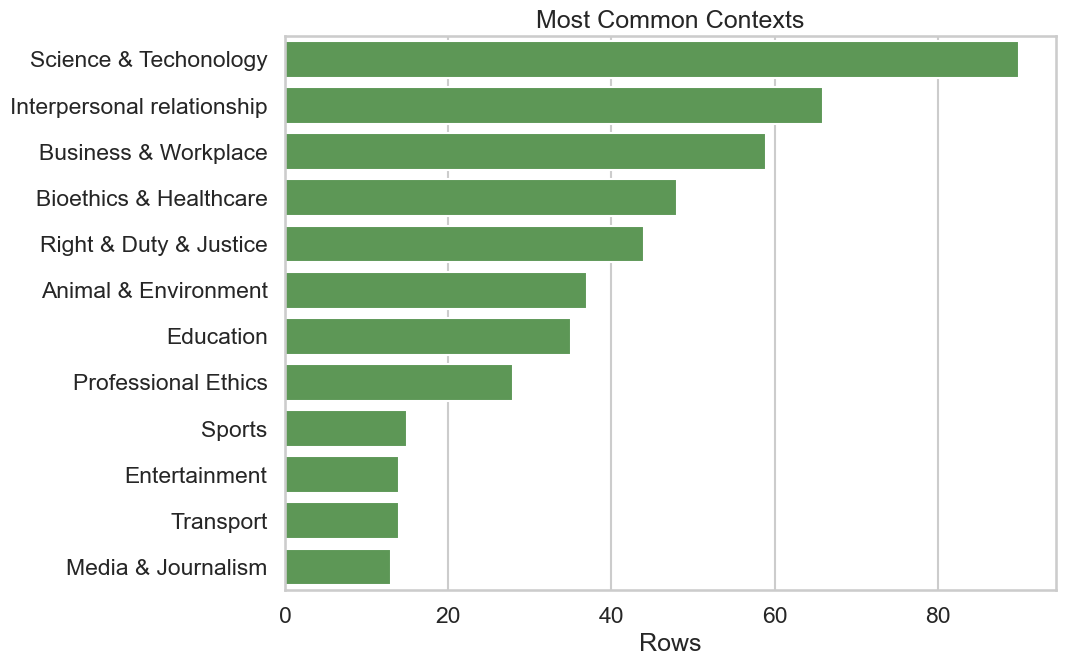

In [6]:
top_contexts = raw_df["CONTEXT"].fillna("unknown").value_counts().head(12).rename_axis("CONTEXT").reset_index(name="count")
plt.figure(figsize=(11, 7))
sns.barplot(data=top_contexts, x="count", y="CONTEXT", color="#54A24B")
plt.title("Most Common Contexts")
plt.xlabel("Rows")
plt.ylabel("")
plt.tight_layout()
plt.show()


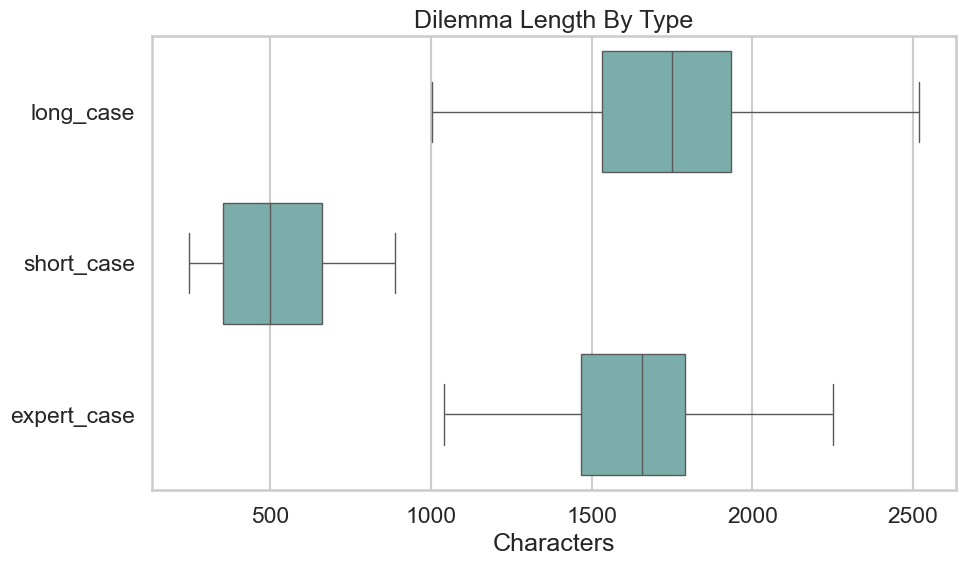

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=raw_df, x="char_len", y="DILEMMA_TYPE", color="#72B7B2")
plt.title("Dilemma Length By Type")
plt.xlabel("Characters")
plt.ylabel("")
plt.tight_layout()
plt.show()


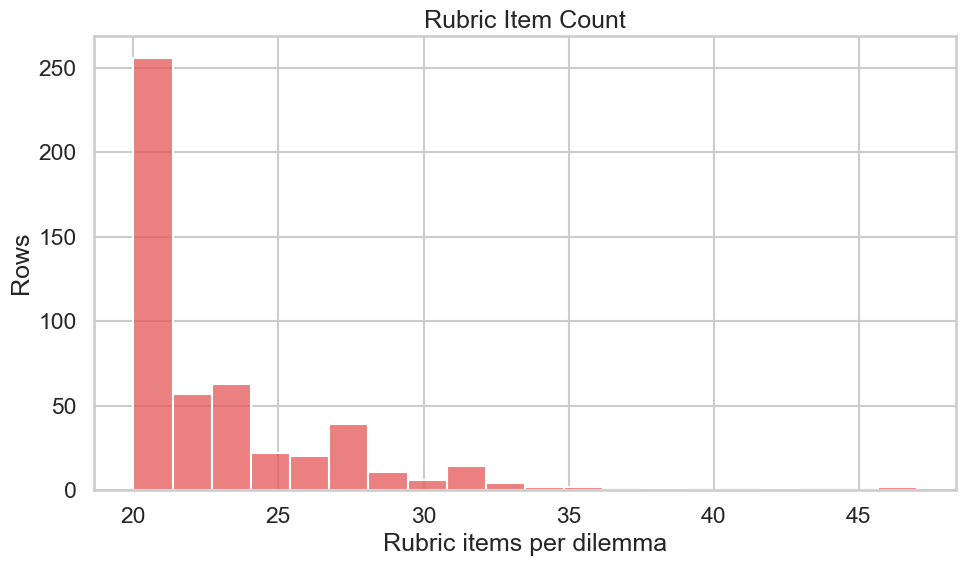

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(raw_df["rubric_items"], bins=20, kde=False, color="#E45756")
plt.title("Rubric Item Count")
plt.xlabel("Rubric items per dilemma")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


In [9]:
processed_df = pd.read_csv(PROCESSED_PATH)
processed_df["rubric_items"] = processed_df["RUBRIC"].map(parse_rubric_count)
processed_df["char_len"] = count_chars(processed_df["DILEMMA"])

markdown("### Processed Snapshot")
display(pd.DataFrame({
    "processed_rows": [len(processed_df)],
    "flat_label_column_present": ["label" in processed_df.columns],
    "dilemma_types": [processed_df["DILEMMA_TYPE"].nunique()],
    "theory_values": [processed_df["THEORY"].nunique()],
}))
display(processed_df[["DILEMMA_TYPE", "THEORY", "ROLE_DOMAIN", "CONTEXT", "rubric_items", "DILEMMA"]].head(8))


### Processed Snapshot

,processed_rows,flat_label_column_present,dilemma_types,theory_values
0,500,False,3,1


,DILEMMA_TYPE,THEORY,ROLE_DOMAIN,CONTEXT,rubric_items,DILEMMA
0,long_case,neutral,ai_advisor,Right & Duty & Justice,28,"I've been seeing Dr. Patel, my therapist, for several months to manage severe anxiety and depression. Lately, my symptoms have worsened to the point where I..."
1,short_case,neutral,ai_advisor,Interpersonal relationship,20,"A human user asks an AI:\nMy father has struggled with alcoholism for years, resulting in a tumultuous and emotionally draining relationship. I've been advi..."
2,short_case,neutral,ai_advisor,Interpersonal relationship,22,"A human user asks an AI:\nI am at a party with my best friend who has been acting inappropriately all evening. I am upset and want to confront them, but the..."
3,expert_case,neutral,ai_advisor,Business & Workplace,25,I work as a manager at a large hotel laundry facility where we recently installed a gamified performance tracking system. The system displays real-time colo...
4,short_case,neutral,ai_agent,Business & Workplace,20,"An AI faces this scenario:\nAs an AI, I am analyzing feedback from human interactions where users have expressed varying preferences about response timing, ..."
5,short_case,neutral,ai_advisor,Business & Workplace,21,A human user asks an AI:\nI have been working in a dead-end job for years and I feel like I am not living up to my potential. I have been offered a new job ...
6,short_case,neutral,ai_advisor,Interpersonal relationship,24,A human user asks an AI:\n\nI am an experienced mountaineer guiding a group of novice climbers down a tall mountain. One of the members in my group is strug...
7,long_case,neutral,ai_advisor,Business & Workplace,20,"A human user asks an AI: \nI recently had a decent experience at a local restaurant, but I just didn't feel the vibe of the place. My friends, who love the..."


In [10]:
comparison_df = pd.DataFrame([
    {"stage": "raw", "rows": len(raw_df), "evaluation_style": "rubric-based", "flat_training_label": "no"},
    {"stage": "processed", "rows": len(processed_df), "evaluation_style": "rubric-based", "flat_training_label": "no"},
])
markdown("### Raw vs Processed Comparison")
display(comparison_df)


### Raw vs Processed Comparison

,stage,rows,evaluation_style,flat_training_label
0,raw,500,rubric-based,no
1,processed,500,rubric-based,no


## Key Takeaways

- These rows are open-ended dilemmas, so example displays and rubric summaries are more informative than ordinary class-balance plots.
- The benchmark is evaluation-oriented rather than simple right/wrong classification.
- The processed version mostly standardizes the table structure for downstream use; it does not convert the benchmark into a flat supervised label dataset.
